In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [5]:
df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [6]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [7]:
df.shape

(1470, 35)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [9]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [10]:
# target value
df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


In [11]:
df.drop(
    columns=[
        "EmployeeCount",
        "EmployeeNumber",
        "Over18",
        "StandardHours"
    ],
    inplace=True
)

In [12]:
# encode the target
df["Attrition"] = df["Attrition"].map({
    "No":0,
    "Yes":1
})

In [13]:
df["Attrition"].value_counts()

,count
Attrition,
0,1233
1,237


In [14]:
#binary column
binary_cols = ["Gender", "OverTime"]

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [15]:
df[["Gender","OverTime"]].head()

,Gender,OverTime
0,0,1
1,1,0
2,1,1
3,0,1
4,1,0


In [16]:
#One-Hot Encode Remaining Columns
df = pd.get_dummies(
    df,
    columns=[
        "BusinessTravel",
        "Department",
        "EducationField",
        "JobRole",
        "MaritalStatus"
    ],
    drop_first=True
)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 45 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int64
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EnvironmentSatisfaction            1470 non-null   int64
 6   Gender                             1470 non-null   int64
 7   HourlyRate                         1470 non-null   int64
 8   JobInvolvement                     1470 non-null   int64
 9   JobLevel                           1470 non-null   int64
 10  JobSatisfaction                    1470 non-null   int64
 11  MonthlyIncome                      1470 non-null   int64
 12  MonthlyRate         

In [18]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
# building the model
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(1176, 44)
(294, 44)
Attrition
0    986
1    190
Name: count, dtype: int64
Attrition
0    247
1     47
Name: count, dtype: int64


In [23]:
# standardizing
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [24]:
X_train_scaled = scaler.fit_transform(X_train)

In [25]:
X_test_scaled = scaler.transform(X_test)

In [26]:
# Train the Model
from sklearn.linear_model import LogisticRegression

In [27]:
model = LogisticRegression(random_state=42)

In [28]:
model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [29]:
y_pred = model.predict(X_test_scaled)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0])

In [30]:
y_prob = model.predict_proba(X_test_scaled)
y_prob

array([[9.26061582e-01, 7.39384179e-02],
       [9.97681723e-01, 2.31827732e-03],
       [8.90692754e-01, 1.09307246e-01],
       [9.93724418e-01, 6.27558183e-03],
       [6.73490243e-01, 3.26509757e-01],
       [7.23784984e-01, 2.76215016e-01],
       [9.92198352e-01, 7.80164803e-03],
       [9.76638542e-01, 2.33614580e-02],
       [9.96890572e-01, 3.10942815e-03],
       [9.15548441e-01, 8.44515595e-02],
       [9.51088521e-01, 4.89114794e-02],
       [9.16077618e-01, 8.39223821e-02],
       [5.90046387e-01, 4.09953613e-01],
       [8.32636437e-01, 1.67363563e-01],
       [7.14241916e-01, 2.85758084e-01],
       [5.91055640e-01, 4.08944360e-01],
       [9.83694415e-01, 1.63055847e-02],
       [9.94685854e-01, 5.31414595e-03],
       [7.32588149e-01, 2.67411851e-01],
       [9.88372709e-01, 1.16272906e-02],
       [5.33346186e-01, 4.66653814e-01],
       [8.96281802e-01, 1.03718198e-01],
       [8.89228020e-01, 1.10771980e-01],
       [9.87131598e-01, 1.28684018e-02],
       [9.957740

In [31]:
# Evaluate the Model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [32]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob[:,1]))

Accuracy : 0.8605442176870748
Precision: 0.6153846153846154
Recall   : 0.3404255319148936
F1 Score : 0.4383561643835616
ROC-AUC  : 0.8079076578516668


In [33]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[237  10]
 [ 31  16]]


In [34]:
# Decision tree
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [35]:
y_pred_dt = dt_model.predict(X_test)

y_prob_dt = dt_model.predict_proba(X_test)

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_dt[:,1]))

Accuracy : 0.7585034013605442
Precision: 0.29310344827586204
Recall   : 0.3617021276595745
F1 Score : 0.3238095238095238
ROC-AUC  : 0.5978551124127831


In [37]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_dt))

[[206  41]
 [ 30  17]]


In [38]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

In [39]:
rf_model = RandomForestClassifier(
    random_state=42
)

In [40]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [41]:
# PREDICTIONS
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)

In [42]:
# evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf[:,1]))

Accuracy : 0.826530612244898
Precision: 0.3
Recall   : 0.06382978723404255
F1 Score : 0.10526315789473684
ROC-AUC  : 0.7864157119476268


In [43]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_rf))

[[240   7]
 [ 44   3]]


In [44]:
# XGBOOST
!pip install xgboost

In [47]:
from xgboost import XGBClassifier

In [48]:
# build the model
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [49]:
# train
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [50]:
# Predictions
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)

In [51]:
# evaluation
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb[:,1]))

Accuracy : 0.8503401360544217
Precision: 0.5789473684210527
Recall   : 0.23404255319148937
F1 Score : 0.3333333333333333
ROC-AUC  : 0.7598415022827117


In [52]:
# SHAP
!pip install shap

In [53]:
import shap

In [54]:
print(X_train.shape)
print(X_train_scaled.shape)
print(X.columns.shape)
print(type(model))

(1176, 44)
(1176, 44)
(44,)
<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [55]:
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X.columns,
    index=X_train.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X.columns,
    index=X_test.index
)

In [56]:
explainer = shap.LinearExplainer(model, X_train_scaled_df)

In [57]:
shap_values = explainer(X_test_scaled_df)

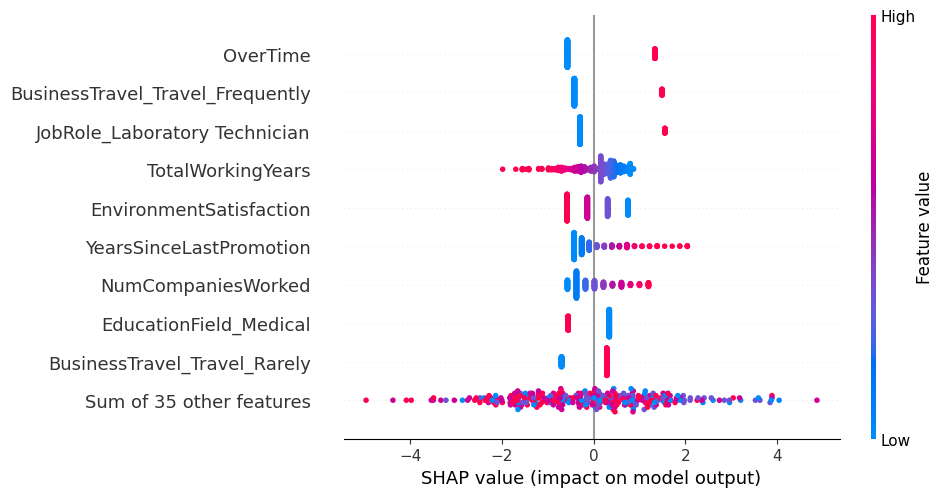

In [58]:
# factors which affect attrition
shap.plots.beeswarm(shap_values)

In [59]:
# employees who were predicted to leave
y_pred = model.predict(X_test_scaled_df)

predicted_leave = X_test[y_pred == 1]

print(predicted_leave)

      Age  DailyRate  DistanceFromHome  Education  EnvironmentSatisfaction  \
397    25        891                 4          2                        2   
514    33       1076                 3          3                        1   
841    24        477                24          3                        4   
132    31        542                20          3                        2   
762    26        342                 2          3                        1   
911    25        599                24          1                        3   
1021   25        383                 9          2                        1   
1168   24        567                 2          1                        1   
824    42        188                29          3                        2   
1391   38       1404                 1          3                        1   
929    28        193                 2          3                        4   
293    26        950                 4          4               

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [60]:
first_leave_index = predicted_leave.index[0]
print(first_leave_index)

397


In [61]:
position = list(X_test.index).index(first_leave_index)
print(position)

25


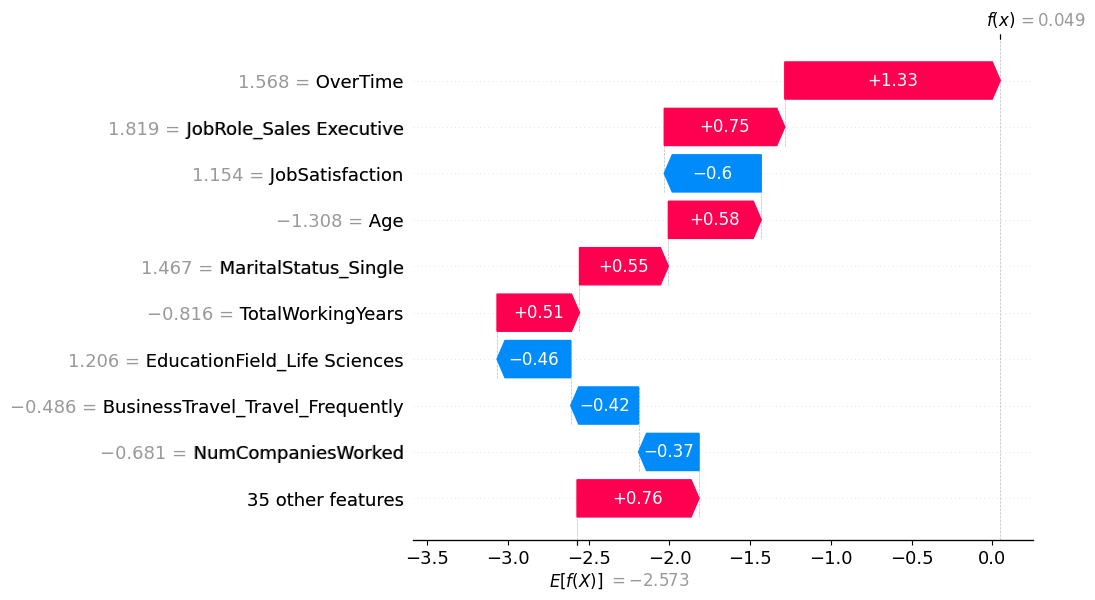

In [62]:
shap.plots.waterfall(shap_values[position])

In [63]:
# in probability
prob = model.predict_proba(X_test_scaled_df)

print(prob[position])

[0.48765467 0.51234533]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


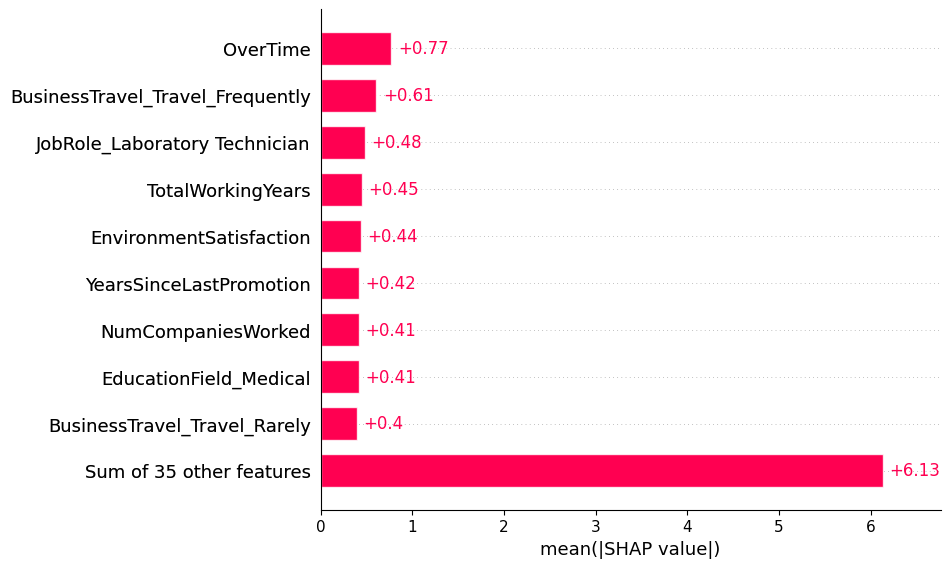

In [64]:
#ranking of feature importance.
shap.plots.bar(shap_values)

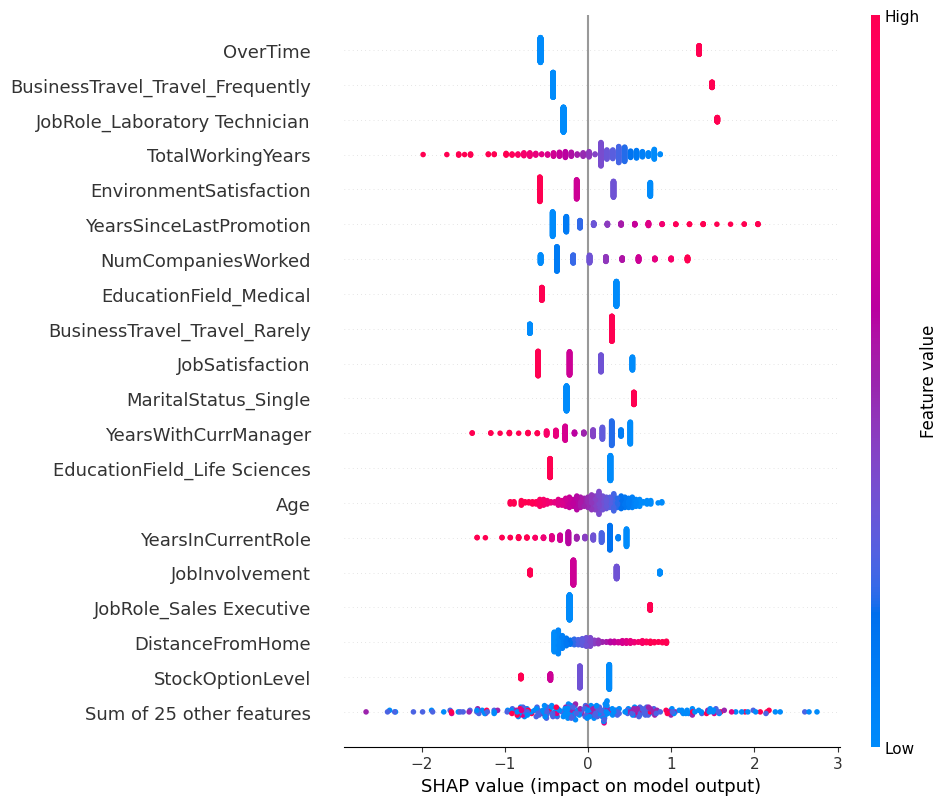

In [65]:
shap.plots.beeswarm(shap_values, max_display=20)

In [71]:
X_scaled_all = scaler.transform(X)

In [72]:
predictions = model.predict(X_scaled_all)

In [73]:
print(predictions[:10])

[1 0 0 0 0 0 0 0 0 0]


In [74]:
probabilities = model.predict_proba(X_scaled_all)[:, 1]

In [75]:
print(probabilities[:10])

[0.72649245 0.01550613 0.43279054 0.10036138 0.41623438 0.07897432
 0.08715779 0.1175639  0.08540851 0.0268509 ]


In [76]:
prediction_df = df.copy()

prediction_df["Predicted_Attrition"] = predictions
prediction_df["Attrition_Probability"] = probabilities

prediction_df["Prediction"] = prediction_df["Predicted_Attrition"].map({
    0: "Stay",
    1: "Leave"
})

prediction_df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,Predicted_Attrition,Attrition_Probability,Prediction
0,41,1,1102,1,2,2,0,94,3,2,...,False,False,False,True,False,False,True,1,0.726492,Leave
1,49,0,279,8,1,3,1,61,2,2,...,False,False,True,False,False,True,False,0,0.015506,Stay
2,37,1,1373,2,2,4,1,92,2,1,...,False,False,False,False,False,False,True,0,0.432791,Stay
3,33,0,1392,3,4,4,0,56,3,1,...,False,False,True,False,False,True,False,0,0.100361,Stay
4,27,0,591,2,1,1,1,40,3,1,...,False,False,False,False,False,True,False,0,0.416234,Stay


In [77]:
prediction_df.to_csv("HR_Predictions.csv", index=False)

In [78]:
from google.colab import files
files.download("HR_Predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>